<a href="https://colab.research.google.com/github/ManuJLV/PracticasIA/blob/main/RNAMushroom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U scikit-learn

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
from sklearn import datasets, metrics, model_selection, svm
from statistics import mode
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import label_binarize
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import RocCurveDisplay
#from sklearn.metrics._plot.roc_curve import auc
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import multilabel_confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Librerias que se van a utilizar


In [ ]:
na_values = ["?"]
names_list = ["class","cap_shape","cap_surface","cap_color","bruises?","odor","gill_attachment","gill_spacing","gill_size","gill_color","stalk_shape","stalk_root","stalk_surface_above_ring","stalk_surface_below_ring","stalk_color_above_ring","stalk_color_below_ring","veil_type","veil_color","ring_number","ring_type","spore_print_color","population","habitat"]
df_mushroom = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data", sep=",",na_values=na_values,header=None, names=names_list)
df_mushroom.head()

,class,cap_shape,cap_surface,cap_color,bruises?,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


# Se importa el dataframe desde https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data
# Y se imprime para verificar que esté bien importado


In [ ]:
df_mushroom.isnull().sum()

class                          0
cap_shape                      0
cap_surface                    0
cap_color                      0
bruises?                       0
odor                           0
gill_attachment                0
gill_spacing                   0
gill_size                      0
gill_color                     0
stalk_shape                    0
stalk_root                  2480
stalk_surface_above_ring       0
stalk_surface_below_ring       0
stalk_color_above_ring         0
stalk_color_below_ring         0
veil_type                      0
veil_color                     0
ring_number                    0
ring_type                      0
spore_print_color              0
population                     0
habitat                        0
dtype: int64

# Se imprimen los valores nulos, en este caso se encuentran todos en la coulumna stalk_root


In [ ]:
#g = df_mushroom[["class","stalk_root"]].groupby(["class"]).
g = df_mushroom.groupby('class').agg({"stalk_root": lambda x: mode(x)})
#print(g["stalk_root"])
df_mushroom['stalk_root'].fillna(df_mushroom['stalk_root'].mode()[0],inplace=True)
df_mushroom['stalk_root'].isnull().sum()

#stalk_root_mode = df_mushroom["stalk_root"].mode()[0]
#print(stalk_root_mode)

0

# Se saca la moda de la columna con los datos nulos siendo agrupados por class, en este caso da b, así que simplemente se rellenan los valores nulos con este valor


In [ ]:
ls = df_mushroom.groupby('class').agg({"bruises?": lambda x: mode(x)})
print(ls)

      bruises?
class         
e            t
p            f


# Una prueba para comprobar que el método para sacar la moda por columna siendo agrupados por class funciona bien, se utiliza la columna bruises? ya que solo tiene valores t o
# f, es más fácil visualizar

In [ ]:
l_names = ["cap_shape","cap_surface","cap_color","bruises?","odor","gill_attachment","gill_spacing","gill_size","gill_color","stalk_shape","stalk_root","stalk_surface_above_ring","stalk_surface_below_ring","stalk_color_above_ring","stalk_color_below_ring","veil_type","veil_color","ring_number","ring_type","spore_print_color","population","habitat"]
input = df_mushroom[l_names]
output = df_mushroom["class"]
np_input = input.to_numpy()
np_output = output.to_numpy()
#input.head()

# Se guardan los datos de entrada y de salida en arreglos numpy

In [ ]:
def codificarDatos(np):
  onehot_encoder=OneHotEncoder(sparse_output=False)
  reshaped=np.reshape(len(np), 1)
  onehot=onehot_encoder.fit_transform(reshaped)
  #print(onehot_encoder.categories_[0])
  return onehot, onehot_encoder.categories_[0]

# Funcion para codificar un objeto tipo numpy

In [ ]:
def codificarEntradas(np_input, l_names):
  dataset = pd.DataFrame()
  names = []
  for i in range(len(l_names)):
    onehot_input, a = codificarDatos(np_input[:,i])
    col_name=[]
    for j in range(len(a)):
      col_name.append(l_names[i] + "_" + a[j])
      names.append(l_names[i] + "_" + a[j])
    #print(col_name)
    df_temp = pd.DataFrame(onehot_input, columns=col_name)
    dataset = pd.concat([dataset, df_temp], axis=1)
  return dataset, names
#print(dataset)
#dataset.head()

# Funcion para codificar múltiples columnas, recibe un numpy array y la lista de nombres de columnas
# **Codifica** cada columna, y luego le coloca los nombres
# Nombre del atributo + _ + cada uno de los valores que puede tomar ese atributo
#Estos mismos nombres se guardan en una lista que los va a contener todos


In [ ]:
col_name = ["comestible", "venenoso"]
df_input, l_input = codificarEntradas(np_input, l_names)
onehot_output, n = codificarDatos(np_output)
#b_output = label_binarize(np_output, classes=np.unique(np_output))
#df_output = pd.DataFrame(b_output, columns=["poisonous"])
df_output = pd.DataFrame(onehot_output, columns=col_name)
dataset = pd.concat([df_output, df_input], axis = 1)
dataset.head()


,comestible,venenoso,cap_shape_b,cap_shape_c,cap_shape_f,cap_shape_k,cap_shape_s,cap_shape_x,cap_surface_f,cap_surface_g,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


# Codificados los datos, a la salida se le asigna los nombres de "comestible", "venenoso"
# Con la lista de nombres de la funcion CodificarEntradas, y los datos codificados se crea un nuevo dataset, luego se concatena el dataset de los datos de salida codificados con este dataset de datos de entrada



In [ ]:
correlation=dataset.corr()
correlation.to_csv('cor.csv')

# Se verifica la correlación de los atributos para ver si es posible descartar columnas, en este caso sí hubo correlación alta entre algunos atributos, sin embargo no se eliminaron columnas

In [ ]:
train, test = train_test_split(dataset, test_size=0.3,shuffle=True)

# Se divide el dataframe en 70% y 30%
#Una prueba fue realizada con 80% y 20%
#Otra con 90% y 10%,
#entre otros valores.
#El resultado fue similar para todos los casos

In [ ]:
#y_train = train["poisonous"]
x_train = train[l_input]
y_train = train[col_name]
#y_test = test["poisonous"]
x_test = test[l_input]
y_test = test[col_name]

#Se dividen los dataset de train y test en entradas y salidas


In [ ]:
classifier = MLPClassifier(solver='adam', activation='relu', alpha=1e-12,tol=1e-16,
                    hidden_layer_sizes=(22,8,2),learning_rate='constant',
                    learning_rate_init=0.001, max_iter=100, verbose=True)

classifier.fit(x_train,y_train)

Iteration 1, loss = 1.37092395
Iteration 2, loss = 1.22448550
Iteration 3, loss = 1.07300158
Iteration 4, loss = 0.90599360
Iteration 5, loss = 0.78117701
Iteration 6, loss = 0.69359808
Iteration 7, loss = 0.64006162
Iteration 8, loss = 0.60678108
Iteration 9, loss = 0.58286200
Iteration 10, loss = 0.56287914
Iteration 11, loss = 0.54601056
Iteration 12, loss = 0.53058319
Iteration 13, loss = 0.51668559
Iteration 14, loss = 0.50372975
Iteration 15, loss = 0.49150419
Iteration 16, loss = 0.48000475
Iteration 17, loss = 0.46885492
Iteration 18, loss = 0.45839606
Iteration 19, loss = 0.44824250
Iteration 20, loss = 0.43822345
Iteration 21, loss = 0.42865788
Iteration 22, loss = 0.41961528
Iteration 23, loss = 0.41046561
Iteration 24, loss = 0.40188836
Iteration 25, loss = 0.39333702
Iteration 26, loss = 0.38508479
Iteration 27, loss = 0.37717173
Iteration 28, loss = 0.36942226
Iteration 29, loss = 0.36188331
Iteration 30, loss = 0.35458041
Iteration 31, loss = 0.34743989
Iteration 32, los

/usr/local/lib/python3.8/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:679: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(alpha=1e-12, hidden_layer_sizes=(22, 8, 2), max_iter=100,
              tol=1e-16, verbose=True)

# Se realiza el entrenamiento de la Red neuronal, el problema es de clasificacion asi que se utiliza MPLClassifier con la siguiente configuracion: solver='adam', activation='relu', alpha=1e-12,tol=1e-16, hidden_layer_sizes=(22,8,2),learning_rate='constant',learning_rate_init=0.001, max_iter=100

#De las configuraciones que probe esta me dio mejores resultados

In [ ]:
test_pred = classifier.predict(x_test)

#Se realizan las predicciones para el x_test

In [ ]:
print(classification_report(y_test, test_pred, zero_division=True))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1243
           1       1.00      1.00      1.00      1195

   micro avg       1.00      1.00      1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438
 samples avg       1.00      1.00      1.00      2438



#Se imprime el reporte comparando y_test con las predicciones hechas, aparentemente el sistema tiene una muy alta tasa de acierto

In [ ]:
cm = multilabel_confusion_matrix(y_test, test_pred)
print(cm)

[[[1195    0]
  [   0 1243]]

 [[1243    0]
  [   0 1195]]]



La matriz de confusion se imprime así debido a que codifiqué las salidas para que quedaran como 2 columnas que toman como valores 0 o 1
También hice pruebas codificando las salidas para que quedara una columna con valores binarios, pero a la hora de entrenar los mejores resultados fueron codificando las salidas con onehot

#De los 2438 datos que se le pasaron a la red para que hiciera sus predicciones, en la ultima ejecuccion al parecer no hay errores


In [ ]:
print("Datos para prueba: "+str(len(x_test)), "Datos de entrenamiento: "+str(len(x_train)), "Datos totales: "+str(len(x_test)+ len(x_train)))

Datos para prueba: 2438 Datos de entrenamiento: 5686 Datos totales: 8124


In [ ]:
metrics.roc_auc_score(y_test, test_pred, multi_class='ovr')

1.0

Se calcula el "Área de cómputo bajo la curva característica operativa del receptor ( AUC ROC ) de los puntajes de predicción"

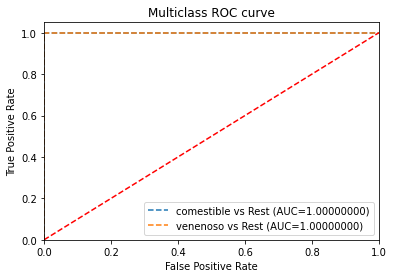

In [ ]:
from pandas.core.dtypes.common import classes

y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
pred_binarized = label_binarize(test_pred, classes=np.unique(test_pred))
#print(y_test_binarized, pred_binarized)
frp = {}
tpr = {}
tresh = {}
roc_auc = dict()
for i in range(2):
  frp[i], tpr[i], tresh[i] = metrics.roc_curve(y_test_binarized[:,i], pred_binarized[:,i])
  roc_auc[i] = auc(frp[i], tpr[i])
  plt.plot(frp[i], tpr[i], linestyle="--", label='%s vs Rest (AUC=%0.8f)'%(col_name[i],roc_auc[i]))
plt.plot([0,1], [0,1], 'r--')
plt.xlim([-0,1])
plt.ylim([0,1.05])
plt.title('Multiclass ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()
#metrics.roc_curve(y_test, test_pred)

# Se hace la grafica de la curva ROC

---
Aparentemente hay un error, ya que en todos los intentos la grafica siempre se ve similar, no tiene la forma que aparece en los ejemplos.



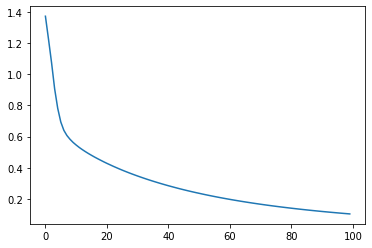

In [ ]:
plt.plot(classifier.loss_curve_)

#Grafica de la curva de error
